# Model Training & Hyperparameter Tuning
This notebook covers the training of the Decision Tree Classifier and performance evaluation.

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')
X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 820, Testing samples: 205


### 1. Grid Search Tuning

In [2]:
dt = DecisionTreeClassifier(random_state=42)
params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(dt, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
model = grid.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_split': 2}


### 2. Evaluation

In [3]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       102
           1       1.00      0.98      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### 3. Visualizing the Decision Tree

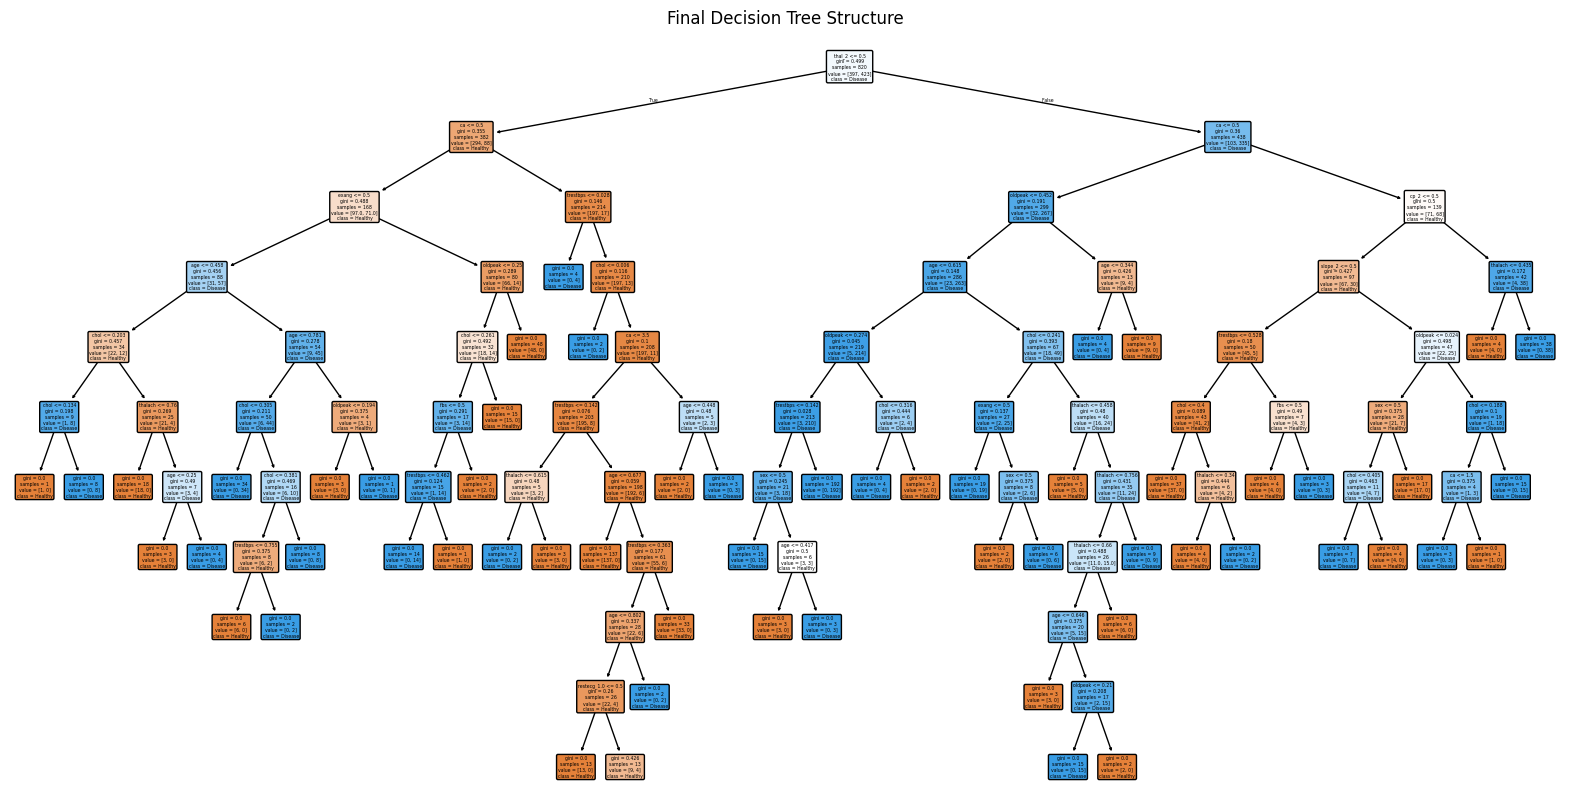

In [4]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Healthy', 'Disease'], filled=True, rounded=True)
plt.title('Final Decision Tree Structure')
plt.show()